
📊 CALCULATING STRICT EVALUATION METRICS
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]
Calculating Metrics: 100%|██████████| 5936/5936 [29:39<00:00,  3.33it/s]



🎯 DETECTION PERFORMANCE (mAP@[0.5:0.95])
Overall mAP@[0.5:0.95] : 0.6568

📈 PER-CLASS DETECTION (AUC & F1 @ 0.5 Thresh)
Short Sleeve Top     | AUC: 0.9223 | F1: 0.8665
Trousers             | AUC: 0.9610 | F1: 0.8132
Shorts               | AUC: 0.9093 | F1: 0.7282
Long Sleeve Top      | AUC: 0.9319 | F1: 0.6640
Skirt                | AUC: 0.9045 | F1: 0.8044

🖼️ ROC Curves saved to: /kaggle/working/detection_roc_curves.png

🧩 SEGMENTATION PERFORMANCE (IoU & Dice)
Short Sleeve Top     | mIoU: 0.5520 | Dice: 0.7114
Trousers             | mIoU: 0.3864 | Dice: 0.5574
Shorts               | mIoU: 0.2361 | Dice: 0.3820
Long Sleeve Top      | mIoU: 0.3057 | Dice: 0.4682
Skirt                | mIoU: 0.4333 | Dice: 0.6046
--------------------------------------------------
🌟 MACRO-AVERAGED mIoU : 0.3827
🌟 MACRO-AVERAGED Dice : 0.5447


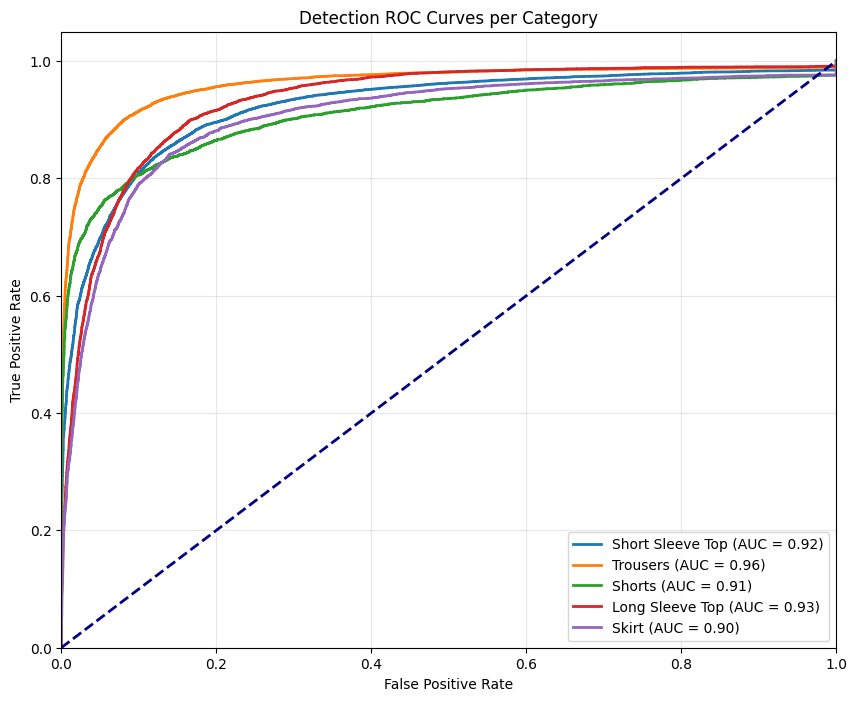

In [1]:
import os
import json
import torch
import numpy as np
import torchvision
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import torchvision.transforms.functional as F
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.ops import box_iou
from sklearn.metrics import roc_curve, auc, f1_score
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*50)
print("📊 CALCULATING STRICT EVALUATION METRICS")
print("="*50)

# ==========================================
# 1. SETUP PATHS & DEVICE
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

VAL_DIR = "/kaggle/input/datasets/hrushi1998/vr-mini-proj-dataset/Trimmed_Dataset/trimmed_val_data"
VAL_JSON = os.path.join(VAL_DIR, "processed_val_data.json")
BEST_MODEL_PATH = "/kaggle/input/notebooks/akshatmittal87/maskrcnn-scratch-10ep/best_maskrcnn_scratch.pth" 

# ==========================================
# 2. DATASET & DATALOADER
# ==========================================
class MasterJSONDataset(Dataset):
    def __init__(self, json_file, img_dir):
        self.img_dir = img_dir
        with open(json_file, 'r') as f:
            self.full_data = json.load(f)["data"]
        self.top_5_categories = [1, 8, 7, 2, 9] 
        self.label_map = {cat_id: idx + 1 for idx, cat_id in enumerate(self.top_5_categories)}

    def __len__(self): return len(self.full_data)

    def __getitem__(self, idx):
        item = self.full_data[idx]
        img_path = os.path.join(self.img_dir, item["image_path"])
        if not os.path.exists(img_path): return None
            
        img = Image.open(img_path).convert("RGB")
        width, height = img.size
        boxes, labels, masks = [], [], []
        
        categories = item.get("item_categories", [])
        bboxes = item.get("detection_bboxes", [])
        polygons = item.get("segmentation_polygons", [])
        
        for i in range(len(categories)):
            cat_id = categories[i]
            if cat_id in self.label_map:
                box = bboxes[i]
                if box[2] <= box[0] or box[3] <= box[1]: continue 
                
                labels.append(self.label_map[cat_id])
                boxes.append(box)
                
                mask = Image.new('L', (width, height), 0)
                draw = ImageDraw.Draw(mask)
                for poly in polygons[i]:
                    draw.polygon(poly, outline=1, fill=1)
                masks.append(np.array(mask))
                    
        if len(boxes) == 0: return None
            
        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
            "masks": torch.as_tensor(np.array(masks), dtype=torch.uint8),
            "image_id": torch.tensor([idx]),
            "area": torch.tensor([(b[2]-b[0])*(b[3]-b[1]) for b in boxes]),
            "iscrowd": torch.zeros((len(labels),), dtype=torch.int64)
        }
        return F.to_tensor(img), target

def custom_collate(batch):
    batch = [b for b in batch if b is not None]
    if not batch: return ()
    return tuple(zip(*batch))

val_loader = DataLoader(MasterJSONDataset(VAL_JSON, VAL_DIR), batch_size=4, shuffle=False, num_workers=2, pin_memory=True, collate_fn=custom_collate)

# ==========================================
# 3. LOAD THE MODEL ARCHITECTURE & WEIGHTS
# ==========================================
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=None, min_size=640, max_size=640)
NUM_CLASSES = 6 
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, NUM_CLASSES)
model.to(device)

checkpoint = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True)
# Handle difference between saving full model vs state_dict
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
model.eval()

# ==========================================
# 4. EXACT METRICS CALCULATION
# ==========================================
box_metrics = MeanAveragePrecision(iou_type="bbox", class_metrics=True)

# Tracking variables for Segmentation (mIoU & Dice)
intersections = np.zeros(NUM_CLASSES)
unions = np.zeros(NUM_CLASSES)
target_areas = np.zeros(NUM_CLASSES)
pred_areas = np.zeros(NUM_CLASSES)

# Tracking variables for Detection (ROC, AUC, F1)
y_scores = {c: [] for c in range(1, NUM_CLASSES)}
y_true = {c: [] for c in range(1, NUM_CLASSES)}

SCORE_THRESH = 0.5 # Confidence threshold for predictions
IOU_THRESH = 0.5   # Box overlap threshold to count as True Positive

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Calculating Metrics"):
        if not batch: continue
        images, targets = batch
        images_gpu = [img.to(device) for img in images]
        targets_gpu = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        outputs = model(images_gpu)
        
        # Format masks for mAP metric update
        for output in outputs:
            output["masks"] = (output["masks"] > 0.5).squeeze(1).to(torch.uint8)
            
        box_metrics.update(outputs, targets_gpu)

        # Custom loop to calculate exact pixel mIoU/Dice and Detection ROC/F1
        for out, tgt, img in zip(outputs, targets_gpu, images):
            img_h, img_w = img.shape[1], img.shape[2]
            
            pred_boxes = out['boxes'].cpu()
            pred_scores = out['scores'].cpu()
            pred_labels = out['labels'].cpu()
            pred_masks = out['masks'].cpu().bool()
            
            tgt_boxes = tgt['boxes'].cpu()
            tgt_labels = tgt['labels'].cpu()
            tgt_masks = tgt['masks'].cpu().bool()
            
            # --- A. SEGMENTATION: Pixel-wise IoU & Dice ---
            for c in range(1, NUM_CLASSES):
                p_masks = pred_masks[pred_labels == c]
                t_masks = tgt_masks[tgt_labels == c]
                
                # Merge multiple instances of the same class into a single semantic mask
                merged_p = p_masks.any(dim=0).numpy() if len(p_masks) > 0 else np.zeros((img_h, img_w), dtype=bool)
                merged_t = t_masks.any(dim=0).numpy() if len(t_masks) > 0 else np.zeros((img_h, img_w), dtype=bool)
                
                intersections[c] += np.logical_and(merged_p, merged_t).sum()
                unions[c] += np.logical_or(merged_p, merged_t).sum()
                pred_areas[c] += merged_p.sum()
                target_areas[c] += merged_t.sum()

            # --- B. DETECTION: Greedy matching for ROC & F1 ---
            for c in range(1, NUM_CLASSES):
                c_p_boxes = pred_boxes[pred_labels == c]
                c_p_scores = pred_scores[pred_labels == c]
                c_t_boxes = tgt_boxes[tgt_labels == c]
                
                if len(c_t_boxes) == 0:
                    for score in c_p_scores: # All False Positives
                        y_scores[c].append(score.item())
                        y_true[c].append(0)
                    continue
                    
                if len(c_p_boxes) == 0:
                    for _ in c_t_boxes: # All False Negatives
                        y_scores[c].append(0.0)
                        y_true[c].append(1)
                    continue
                
                ious = box_iou(c_p_boxes, c_t_boxes)
                matched_tgts = set()
                
                for i, score in enumerate(c_p_scores):
                    max_iou, best_idx = (0, -1)
                    if ious.shape[1] > 0:
                        max_iou, best_idx = ious[i].max(dim=0)
                        max_iou, best_idx = max_iou.item(), best_idx.item()
                    
                    if max_iou >= IOU_THRESH and best_idx not in matched_tgts:
                        y_scores[c].append(score.item())
                        y_true[c].append(1) # True Positive
                        matched_tgts.add(best_idx)
                    else:
                        y_scores[c].append(score.item())
                        y_true[c].append(0) # False Positive
                        
                # Add remaining missed targets as False Negatives
                unmatched = len(c_t_boxes) - len(matched_tgts)
                for _ in range(unmatched):
                    y_scores[c].append(0.0)
                    y_true[c].append(1)

# ==========================================
# 5. PRINT OUTPUTS & SAVE CHARTS
# ==========================================
cat_names = {1: "Short Sleeve Top", 2: "Trousers", 3: "Shorts", 4: "Long Sleeve Top", 5: "Skirt"}

print("\n" + "="*50)
print("🎯 DETECTION PERFORMANCE (mAP@[0.5:0.95])")
print("="*50)
final_box = box_metrics.compute()
print(f"Overall mAP@[0.5:0.95] : {final_box['map'].item():.4f}")

print("\n" + "="*50)
print("📈 PER-CLASS DETECTION (AUC & F1 @ 0.5 Thresh)")
print("="*50)
plt.figure(figsize=(10, 8))
for c in range(1, NUM_CLASSES):
    if len(y_true[c]) == 0: continue
    
    y_t = np.array(y_true[c])
    y_s = np.array(y_scores[c])
    
    # Calculate AUC
    fpr, tpr, _ = roc_curve(y_t, y_s)
    roc_auc = auc(fpr, tpr)
    
    # Calculate F1-Score (Applying confidence threshold)
    y_pred_binary = (y_s >= SCORE_THRESH).astype(int)
    f1 = f1_score(y_t, y_pred_binary, zero_division=0)
    
    name = cat_names.get(c, f"Class {c}")
    print(f"{name:<20} | AUC: {roc_auc:.4f} | F1: {f1:.4f}")
    
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Detection ROC Curves per Category')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig("/kaggle/working/detection_roc_curves.png", dpi=300)
print("\n🖼️ ROC Curves saved to: /kaggle/working/detection_roc_curves.png")

print("\n" + "="*50)
print("🧩 SEGMENTATION PERFORMANCE (IoU & Dice)")
print("="*50)
class_ious, class_dices = [], []
for c in range(1, NUM_CLASSES):
    iou = intersections[c] / (unions[c] + 1e-6)
    dice = (2 * intersections[c]) / (pred_areas[c] + target_areas[c] + 1e-6)
    class_ious.append(iou)
    class_dices.append(dice)
    name = cat_names.get(c, f"Class {c}")
    print(f"{name:<20} | mIoU: {iou:.4f} | Dice: {dice:.4f}")

print("-" * 50)
print(f"🌟 MACRO-AVERAGED mIoU : {np.mean(class_ious):.4f}")
print(f"🌟 MACRO-AVERAGED Dice : {np.mean(class_dices):.4f}")
print("="*50)